In [4]:
import pandas as pd
import matplotlib.pyplot as plt

In [5]:
data = pd.read_csv("../data/demanda_comercial.csv.zip", compression="zip")
data.head()

,Fecha,H01,H02,H03,H04,H05,H06,H07,H08,H09,...,H15,H16,H17,H18,H19,H20,H21,H22,H23,H24
0,2017-01-01,6090271.96,5887031.28,5708693.89,5538133.02,5389774.53,5288199.94,4851217.85,4876162.18,5073813.27,...,5745568.87,5647807.40,5609297.84,5690105.56,6761038.26,7077861.59,6979468.90,6695312.12,6289107.72,5794545.98
1,2017-01-02,5557603.42,5361012.17,5239119.86,5163721.70,5249539.75,5438852.95,5566947.57,6055220.80,6588005.66,...,7610559.73,7584026.97,7421194.49,7317194.26,8182697.67,8482127.69,8251009.75,7836278.95,7221234.85,6660691.64
2,2017-01-03,6160676.02,5924880.04,5764416.93,5685832.28,5778222.13,5985840.29,6083907.36,6545100.21,7092804.54,...,8148614.93,8117168.00,7930900.03,7783762.28,8653467.38,8835882.88,8562448.23,8095841.79,7443299.51,6840297.15
3,2017-01-04,6321851.20,6092135.24,5905390.85,5827867.82,5925730.02,6182279.89,6276759.96,6737660.53,7256819.19,...,8164513.51,8132006.92,7962749.39,7841533.59,8700506.07,8860255.66,8611085.76,8147451.75,7471240.82,6838250.32
4,2017-01-05,6395397.96,6162409.22,6001153.67,5918673.26,6005924.21,6225027.53,6322923.78,6739120.44,7307847.42,...,8144209.65,8136193.07,8022918.36,7927405.07,8718181.89,8832234.87,8579992.47,8063978.64,7406615.66,6829864.57


In [6]:
# Se organizan los datos para graficarlos.

data_to_plot = data.copy()
data_to_plot = data_to_plot.melt(
    id_vars=["Fecha"], var_name="hora", value_name="demanda"
)
data_to_plot = data_to_plot.sort_values(by=["Fecha", "hora"])
data_to_plot = data_to_plot.reset_index(drop=True)
data_to_plot = data_to_plot.head(500)
data_to_plot.head() 

,Fecha,hora,demanda
0,2017-01-01,H01,6090271.96
1,2017-01-01,H02,5887031.28
2,2017-01-01,H03,5708693.89
3,2017-01-01,H04,5538133.02
4,2017-01-01,H05,5389774.53


AttributeError: 'Series' object has no attribute 'avg'

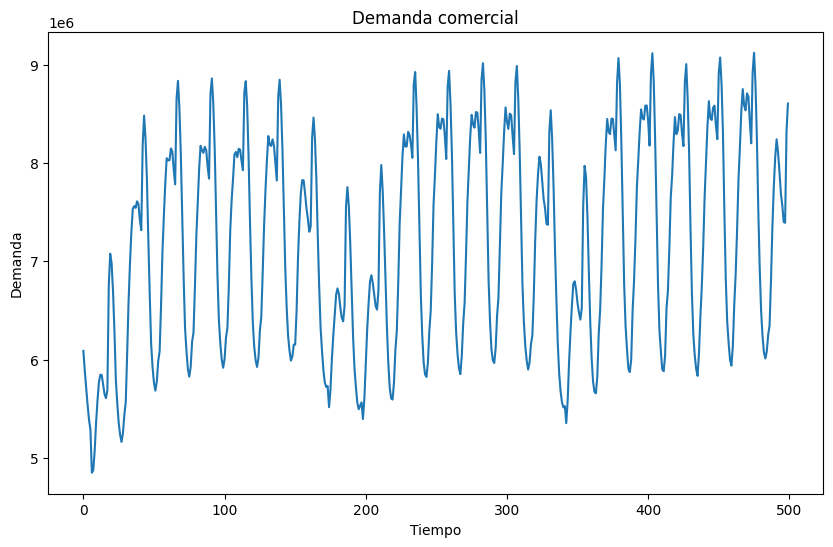

In [ ]:
series = data_to_plot["demanda"]
avg = series.mean()

plt.figure(figsize=(10, 6))
plt.plot(series, color="blue", linewidth=1)
plt.title("Demanda comercial")
plt.xlabel("Tiempo")
plt.ylabel("Demanda")
plt.axhline(y=avg, color="red", linestyle="--", linewidth=1, label=f"Promedio: {avg:.2f}")
plt.plot(data_to_plot["demanda"], color="blue", linewidth=1)
plt.grid()
plt.savefig("../submission/demanda-comercial.png")
plt.show()

In [9]:
# Preparación de la data

data = data.dropna()
data = data.drop_duplicates()
data = data.set_index("Fecha")

data.head()

,H01,H02,H03,H04,H05,H06,H07,H08,H09,H10,...,H15,H16,H17,H18,H19,H20,H21,H22,H23,H24
Fecha,,,,,,,,,,,,,,,,,,,,,
2017-01-01,6090271.96,5887031.28,5708693.89,5538133.02,5389774.53,5288199.94,4851217.85,4876162.18,5073813.27,5359713.29,...,5745568.87,5647807.40,5609297.84,5690105.56,6761038.26,7077861.59,6979468.90,6695312.12,6289107.72,5794545.98
2017-01-02,5557603.42,5361012.17,5239119.86,5163721.70,5249539.75,5438852.95,5566947.57,6055220.80,6588005.66,6979088.72,...,7610559.73,7584026.97,7421194.49,7317194.26,8182697.67,8482127.69,8251009.75,7836278.95,7221234.85,6660691.64
2017-01-03,6160676.02,5924880.04,5764416.93,5685832.28,5778222.13,5985840.29,6083907.36,6545100.21,7092804.54,7461185.94,...,8148614.93,8117168.00,7930900.03,7783762.28,8653467.38,8835882.88,8562448.23,8095841.79,7443299.51,6840297.15
2017-01-04,6321851.20,6092135.24,5905390.85,5827867.82,5925730.02,6182279.89,6276759.96,6737660.53,7256819.19,7608691.40,...,8164513.51,8132006.92,7962749.39,7841533.59,8700506.07,8860255.66,8611085.76,8147451.75,7471240.82,6838250.32
2017-01-05,6395397.96,6162409.22,6001153.67,5918673.26,6005924.21,6225027.53,6322923.78,6739120.44,7307847.42,7619827.03,...,8144209.65,8136193.07,8022918.36,7927405.07,8718181.89,8832234.87,8579992.47,8063978.64,7406615.66,6829864.57


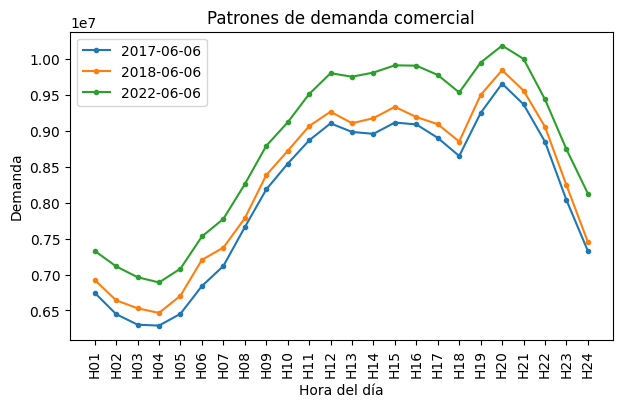

In [15]:
# Patrones de ejemplo

meses = ["2017-06-06", "2018-06-06", "2022-06-06"]

plt.figure(figsize=(7, 4))
for mes in meses:
    plt.plot(data.loc[mes], ".-", label=mes)
plt.title("Patrones de demanda comercial")
plt.xlabel("Hora del día")
plt.ylabel("Demanda")
plt.legend(meses)
plt.xticks(rotation=90)
plt.show()